In [ ]:
from scripts.utils.utils import *
from scripts.preprocessing.preprocessing import *
from scripts.preprocessing.data_loader import ThermalDataset

from skimage.feature import hog
import numpy as np
import os
from pathlib import Path
from dotenv import load_dotenv

import random

In [ ]:
load_dotenv()
ROOT_DIR = Path(os.getenv("ROOT_DIR"))

data_path = ROOT_DIR / "data"

In [ ]:
images_dir = ROOT_DIR / "data" / "images"
masks_dir = ROOT_DIR / "data" / "mask_merged"
print("Images directory: ", images_dir, " Masks directory: ", masks_dir)

dataset = ThermalDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    height=256, 
    width=384,
)
print("Number of images: ", len(dataset))

Images directory:  ../BCXTT/data/images  Masks directory:  ../BCXTT/data/mask_merged
Number of images:  244


In [ ]:
id_image = random.randint(0, 200)
print("Random image ID: ", id_image)
id_image = 3

image, mask = dataset[id_image]
image = image.numpy()
mask = mask.numpy()
print("Image shape: ", image.shape)

Random image ID:  18
Image shape:  (1, 256, 384)


In [43]:
print(f"Min value of the original image: {image.min()}")
print(f"Max value of the original image: {image.max()}")
print(f"Shape of the original image: {image.shape}")

Min value of the original image: 0.0
Max value of the original image: 1.0
Shape of the original image: (1, 256, 384)


## Cropping

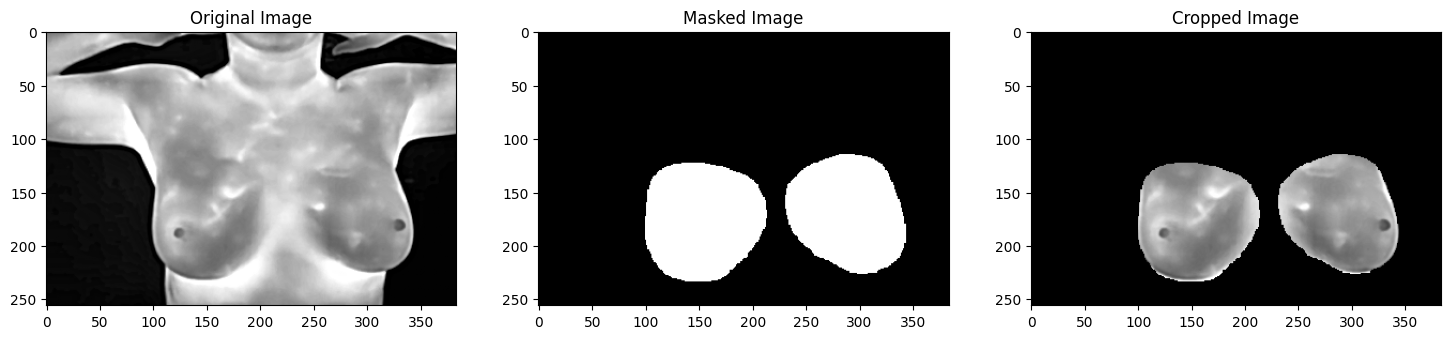

In [ ]:
image = image[0]
image = preprocess_raw_image(image)
cropped = image * mask
cropped = cropped.astype(np.float32)

fig, ax = plt.subplots(1, 3, figsize=(18, 8))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Original Image")
ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Masked Image")
ax[2].imshow(cropped, cmap="gray")
ax[2].set_title("Cropped Image")
plt.show()

In [48]:
print(image.shape, mask.shape, cropped.shape)
cropped_images, cropped_masks = crop_breasts(image, mask)
print(f"Number of cropped images: {len(cropped_images)}, Number of cropped masks: {len(cropped_masks)}")

(256, 384) (256, 384) (256, 384)
Number of cropped images: 2, Number of cropped masks: 2


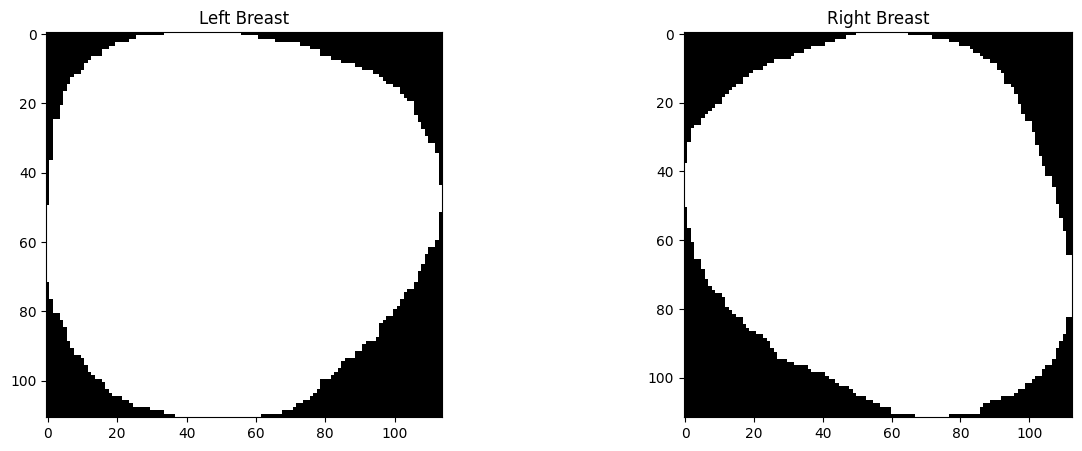

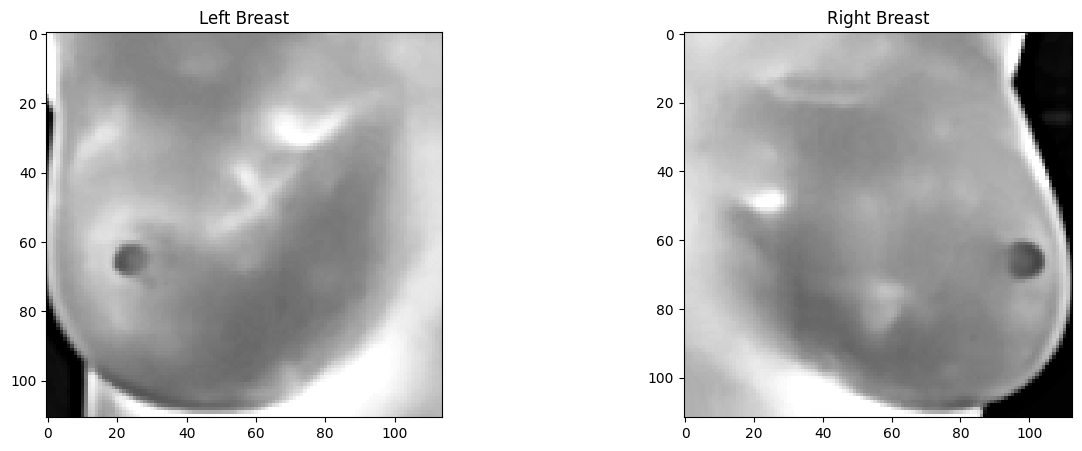

In [49]:
left = cropped_images[0]
right = cropped_images[1]
left_mask = cropped_masks[0]
right_mask = cropped_masks[1]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(left_mask, cmap="gray")
ax[0].set_title("Left Breast")
ax[1].imshow(right_mask, cmap="gray")
ax[1].set_title("Right Breast")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(left, cmap="gray")
ax[0].set_title("Left Breast")
ax[1].imshow(right, cmap="gray")
ax[1].set_title("Right Breast")
plt.show()

In [ ]:
patch_size = 100
left = reshape_array(left, patch_size, patch_size)[0]
left_mask = reshape_array(left_mask, patch_size, patch_size)[0]
left = np.flip(left, axis=1)
left_mask = np.flip(left_mask, axis=1)

right = reshape_array(right, patch_size, patch_size)[0]
right_mask = reshape_array(right_mask, patch_size, patch_size)[0]
print(left.shape)
print(right.shape)

(100, 100)
(100, 100)


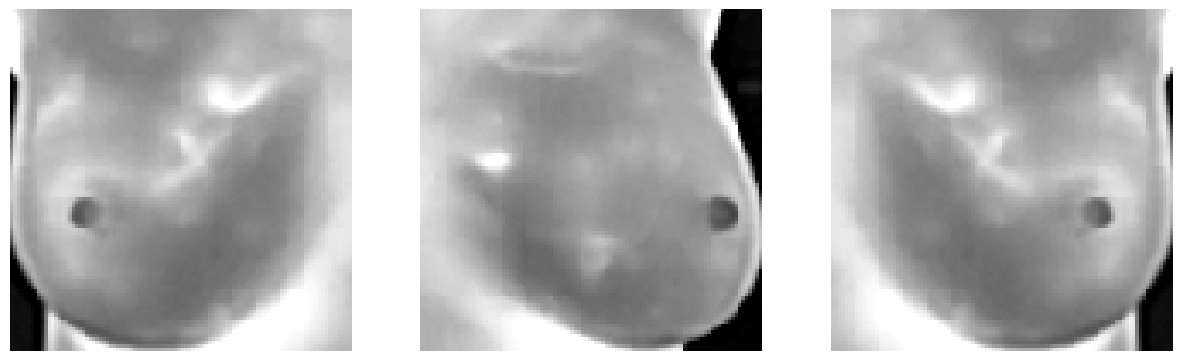

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(np.flip(left, axis=1), cmap="gray")
ax[0].set_title("Left Breast")
ax[0].axis("off")
ax[1].imshow(right, cmap="gray")
ax[1].set_title("Right Breast")
ax[1].axis("off")
ax[2].imshow(left, cmap="gray")
ax[2].set_title("Flipped Left Breast")
ax[2].axis("off")
plt.show()

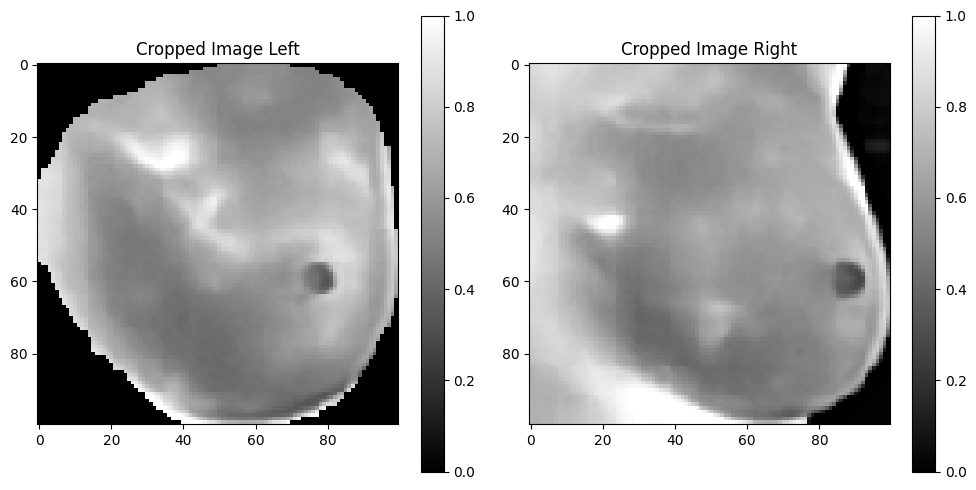

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(left, cmap="gray")
ax[0].set_title("Cropped Image Left")
ax[1].imshow(right, cmap="gray")
ax[1].set_title("Cropped Image Right")

plt.colorbar(ax[0].imshow(left * left_mask, cmap="gray"), ax=ax[0])
plt.colorbar(ax[1].imshow(right, cmap="gray"), ax=ax[1])
plt.tight_layout()
plt.show()

## Frangi e white tophat

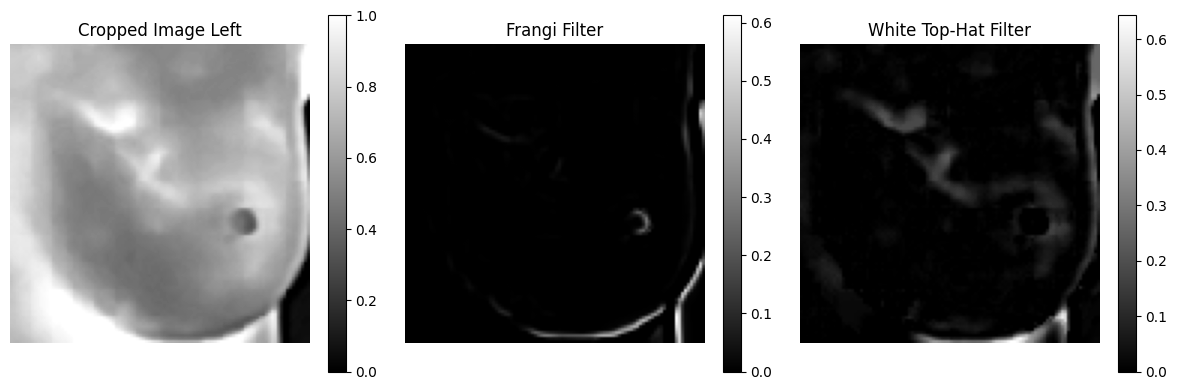

In [ ]:
from skimage.filters import frangi
from skimage.morphology import white_tophat, disk

def apply_frangi(image):
    return frangi(image)

def apply_white_tophat(image, radius=5):
    selem = disk(radius)
    return white_tophat(image, selem)

frangi_image = apply_frangi(left)
tophat_image = apply_white_tophat(left)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(left, cmap="gray")
ax[0].axis("off")
ax[0].set_title("Cropped Image Left")
ax[1].imshow(frangi_image, cmap="gray")
ax[1].axis("off")
ax[1].set_title("Frangi Filter")
ax[2].imshow(tophat_image, cmap="gray")
ax[2].axis("off")
ax[2].set_title("White Top-Hat Filter")
plt.colorbar(ax[0].imshow(left, cmap="gray"), ax=ax[0])
plt.colorbar(ax[1].imshow(frangi_image, cmap="gray"), ax=ax[1])
plt.colorbar(ax[2].imshow(tophat_image, cmap="gray"), ax=ax[2])
plt.tight_layout()
plt.show()

# Hog on cropped visualization

In [16]:
p = 12
c = 1

Left - Feature shape: (576,)
Left - HoG image shape: (100, 100)
Right - Feature shape: (576,)
Right - HoG image shape: (100, 100)


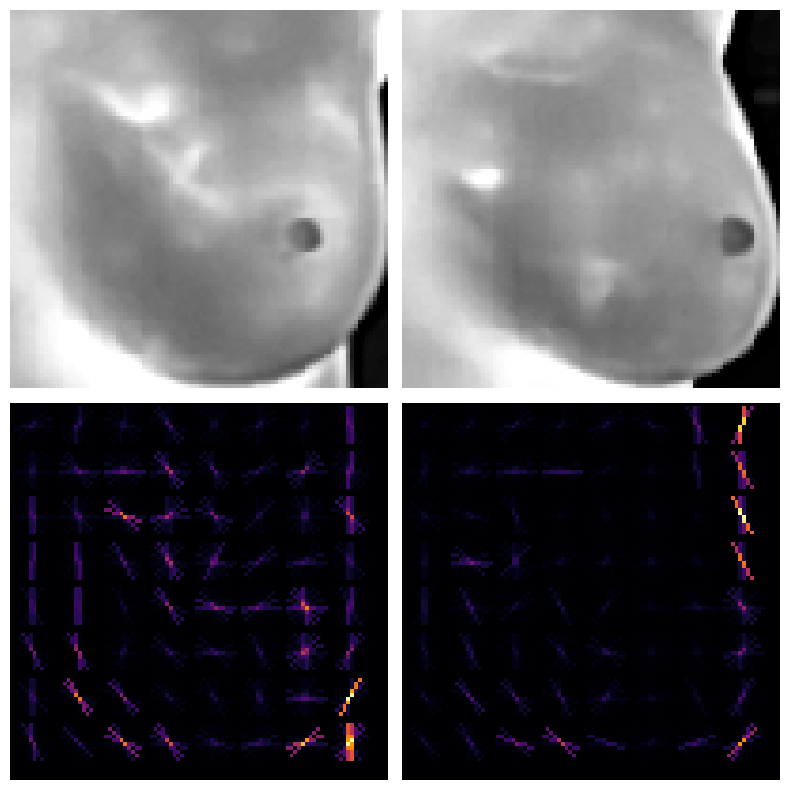

In [ ]:
features_left, hog_image_left = hog(left,
                                    orientations=9,
                                    pixels_per_cell=(p, p),
                                    cells_per_block=(c, c),
                                    visualize=True,
                                    feature_vector=True)
features_right, hog_image_right = hog(right,
                                      orientations=9,
                                      pixels_per_cell=(p, p),
                                      cells_per_block=(c, c),
                                      visualize=True,
                                      feature_vector=True)

print("Left - Feature shape:", features_left.shape)
print("Left - HoG image shape:", hog_image_left.shape)
print("Right - Feature shape:", features_right.shape)
print("Right - HoG image shape:", hog_image_right.shape)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(left, cmap='gray')
axes[0, 0].set_title("Raw Image Left")
axes[0, 0].axis('off')
axes[0, 1].imshow(right, cmap='gray')
axes[0, 1].set_title("Raw Image Right")
axes[0, 1].axis('off')
axes[1, 0].imshow(hog_image_left, cmap='inferno')
axes[1, 0].set_title("HoG Visualization Left")
axes[1, 0].axis('off')
axes[1, 1].imshow(hog_image_right, cmap='inferno')
axes[1, 1].set_title("HoG Visualization Right")
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

## Delta in Image

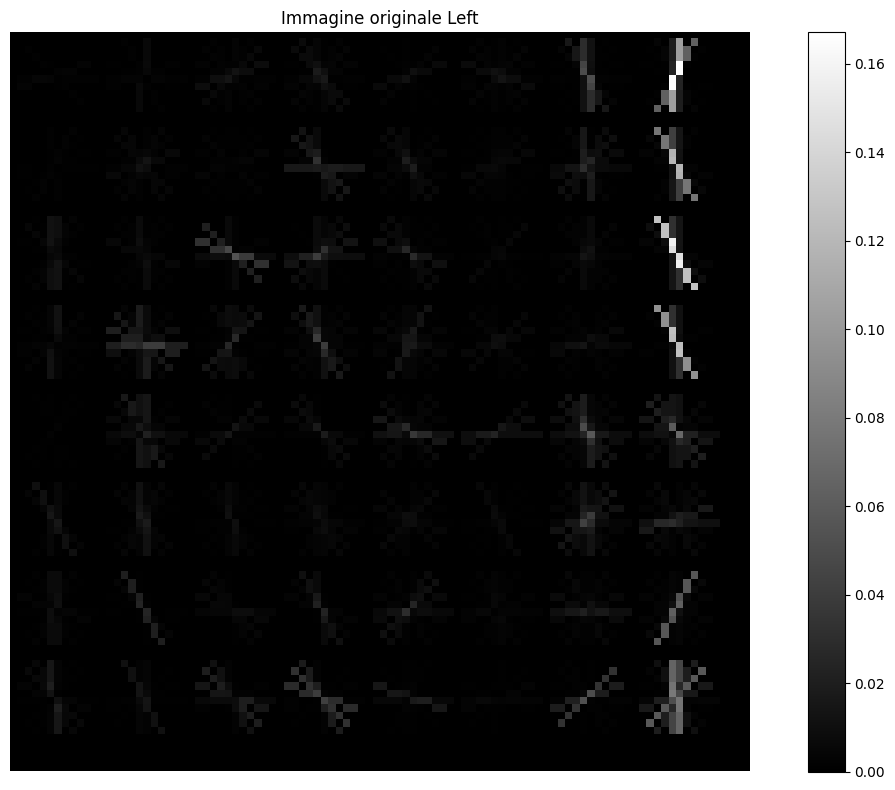

In [18]:
plt.figure(figsize=(12, 8))
delta_image = hog_image_left - hog_image_right
delta_image = np.abs(delta_image)
plt.imshow(delta_image, cmap='gray')
plt.colorbar()
plt.title("Immagine originale Left")
plt.axis('off')
plt.tight_layout()
plt.show()

## Hog Delta

In [19]:

hog_left = hog(left, orientations=9, pixels_per_cell=(p, p),
               cells_per_block=(c, c), visualize=False, feature_vector=True)

hog_right = hog(right, orientations=9, pixels_per_cell=(p, p),
                cells_per_block=(c, c), visualize=False, feature_vector=True)

print("HOG Left Shape: ", hog_left.shape)
print("HOG Right Shape: ", hog_right.shape)

HOG Left Shape:  (576,)
HOG Right Shape:  (576,)


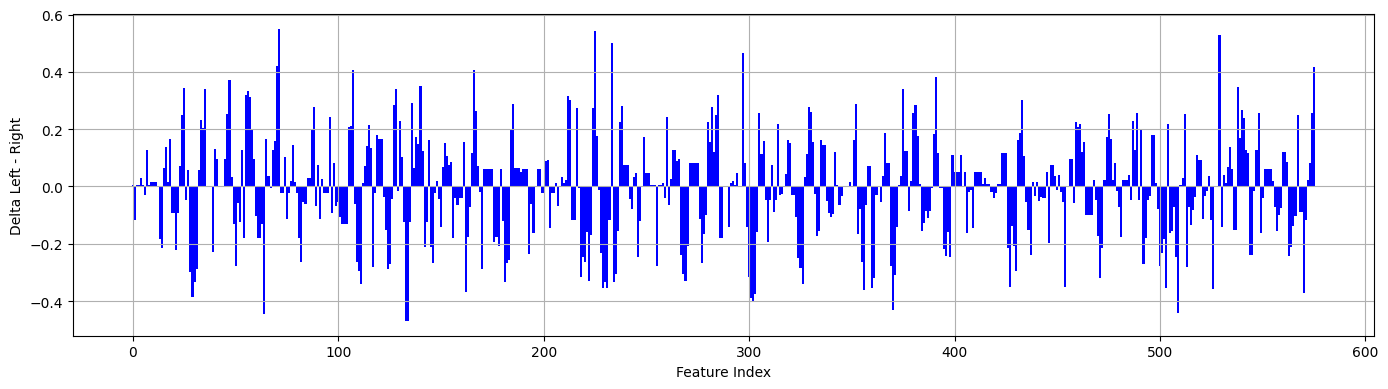

In [ ]:
hog_delta = hog_left - hog_right
#hog_delta = np.abs(hog_delta)

# mean sliding to create average moving. 

plt.figure(figsize=(14, 4))
plt.bar(np.arange(len(hog_delta)), hog_delta, color='blue', width=1.0)
plt.title("Delta concatenated HoG Features (Left - Right)")
plt.xlabel("Feature Index")
plt.ylabel("Delta Left - Right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Fuzzy k-means

In [21]:
import skfuzzy as fuzz

n_clusters = 4
m = 2.0

pixels_left = left.flatten()
pixels_left = pixels_left[np.newaxis, :]
pixels_right = right.flatten()
pixels_right = pixels_right[np.newaxis, :]

centers, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data = pixels_left,
    c = n_clusters,
    m = m,
    error = 0.005,
    maxiter = 1000,
    init = None,
)

In [ ]:
hard_labels = np.argmax(u, axis=0)
segmented_image_hardcoded = hard_labels.reshape(left.shape)

# find the high temperature cluster
pixels_left = pixels_left.flatten()

means = []
stds = []
for i in range(n_clusters):
    cluster_pixels = pixels_left[hard_labels == i]
    mean_val = cluster_pixels.mean()
    std_val = cluster_pixels.std()
    means.append(mean_val)
    stds.append(std_val)
    print(f"Cluster {i}: Media = {mean_val:.4f}, Std = {std_val:.4f}, Count = {len(cluster_pixels)}")

best_cluster = np.argmax(means)
second_best_cluster = np.argsort(means)[-2]
print(f"\n➡️  Cluster con media pixel più alta: {best_cluster} (Media = {means[best_cluster]:.4f})")

segmented_image_high_temp = u[best_cluster, :]
segmented_image_high_temp = segmented_image_high_temp.reshape(left.shape)

segmented_image_high_temp_second = u[second_best_cluster, :]
segmented_image_high_temp_second = segmented_image_high_temp_second.reshape(left.shape)

Cluster 0: Media = 0.5651, Std = 0.0418, Count = 3204
Cluster 1: Media = 0.7220, Std = 0.0467, Count = 3560
Cluster 2: Media = 0.9036, Std = 0.0635, Count = 1682
Cluster 3: Media = 0.3868, Std = 0.1498, Count = 1554

➡️  Cluster con media pixel più alta: 2 (Media = 0.9036)


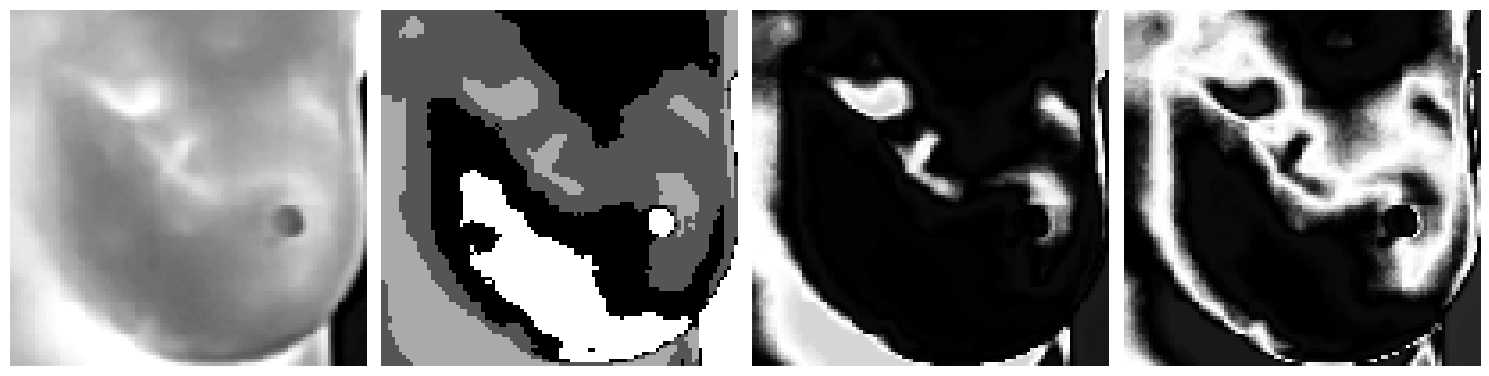

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(left, cmap="gray")
ax[0].axis('off')
ax[0].set_title("Original Image")
ax[1].imshow(segmented_image_hardcoded, cmap="gray")
ax[1].axis('off')
ax[1].set_title("Clustered")
ax[2].imshow(segmented_image_high_temp, cmap="gray")
ax[2].axis('off')
ax[2].set_title("Highest Temperature Cluster")
ax[3].imshow(segmented_image_high_temp_second, cmap="gray")
ax[3].axis('off')
ax[3].set_title("Segmented Image High Temp Second")
plt.tight_layout()
plt.show()

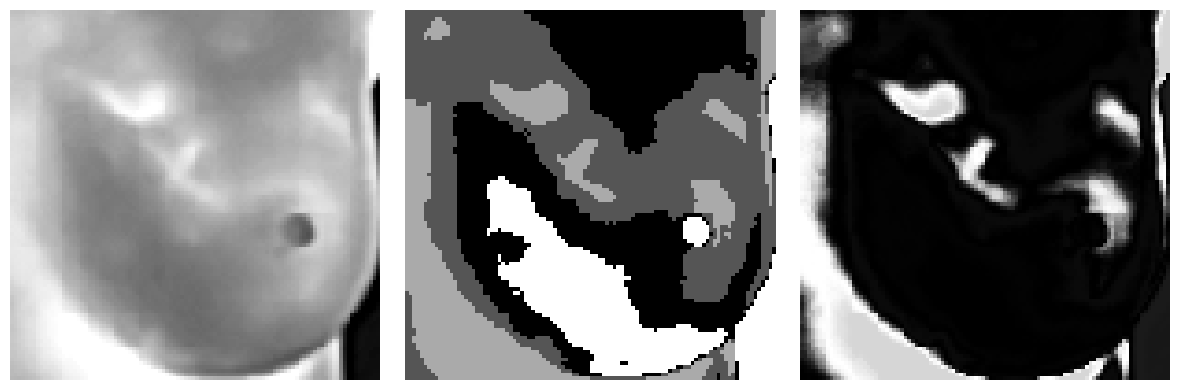

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(left, cmap="gray")
ax[0].axis('off')
ax[0].set_title("Original Image")
ax[1].imshow(segmented_image_hardcoded, cmap="gray")
ax[1].axis('off')
ax[1].set_title("Clustered")
ax[2].imshow(segmented_image_high_temp, cmap="gray")
ax[2].axis('off')
ax[2].set_title("Highest Temperature Cluster")
plt.tight_layout()
plt.show()

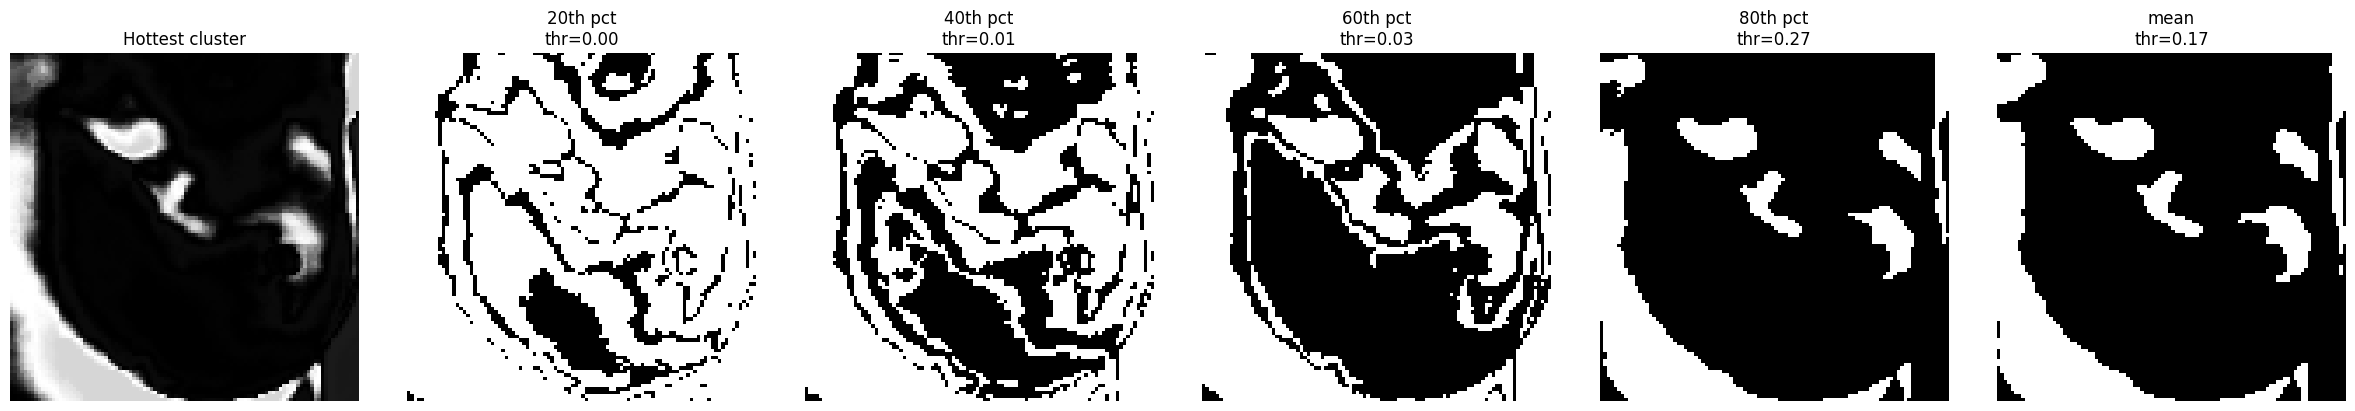

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

percentiles = [20, 40, 60, 80]
thresholds = [np.percentile(segmented_image_high_temp, p) for p in percentiles]
thresholds.append(segmented_image_high_temp.mean())

labels = [f"{p}th pct" for p in percentiles] + ["mean"]

n_cols = len(thresholds) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(4*n_cols, 4))

axes[0].imshow(segmented_image_high_temp, cmap='gray')
axes[0].set_title("Hottest cluster")
axes[0].axis('off')

for i, (thr, label) in enumerate(zip(thresholds, labels), start=1):
    mask = segmented_image_high_temp > thr
    axes[i].imshow(mask, cmap='gray')
    axes[i].set_title(f"{label}\nthr={thr:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

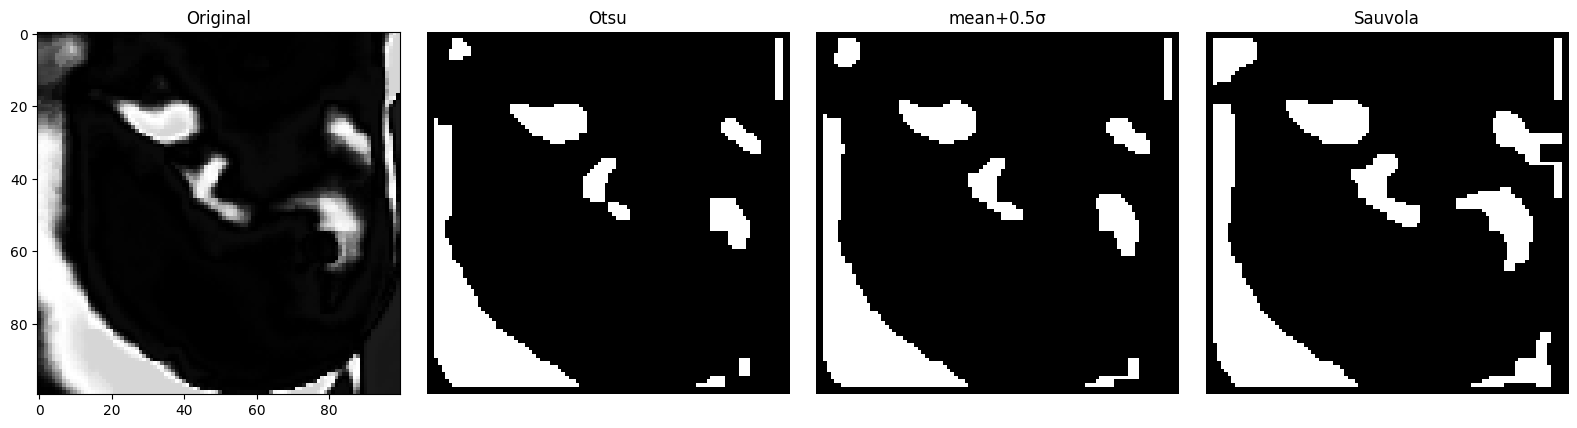

In [26]:
import numpy as np
import cv2
import scipy.ndimage as ndi
from skimage.filters import threshold_otsu, threshold_sauvola

M = segmented_image_high_temp 

flat = (M*255).astype(np.uint8)
th_otsu = threshold_otsu(flat)/255

mask1 = M > th_otsu
mu, sigma = M.mean(), M.std()
mask2 = M > (mu + 0.5*sigma)

th_loc = threshold_sauvola(M, window_size=51)
mask3 = M > th_loc

def clean(mask):
    m = ndi.binary_opening(mask, structure=np.ones((3,3)))
    m = ndi.binary_closing(m, structure=np.ones((5,5)))
    return ndi.binary_fill_holes(m)

mask1 = clean(mask1)
mask2 = clean(mask2)
mask3 = clean(mask3)

import matplotlib.pyplot as plt
fig, axs = plt.subplots(1,4, figsize=(16,4))
axs[0].imshow(segmented_image_high_temp, cmap='gray'); axs[0].set_title('Original')
for ax, (m, title) in zip(axs[1:], [(mask1,'Otsu'),(mask2,'mean+0.5σ'),(mask3,'Sauvola')]):
    ax.imshow(m, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


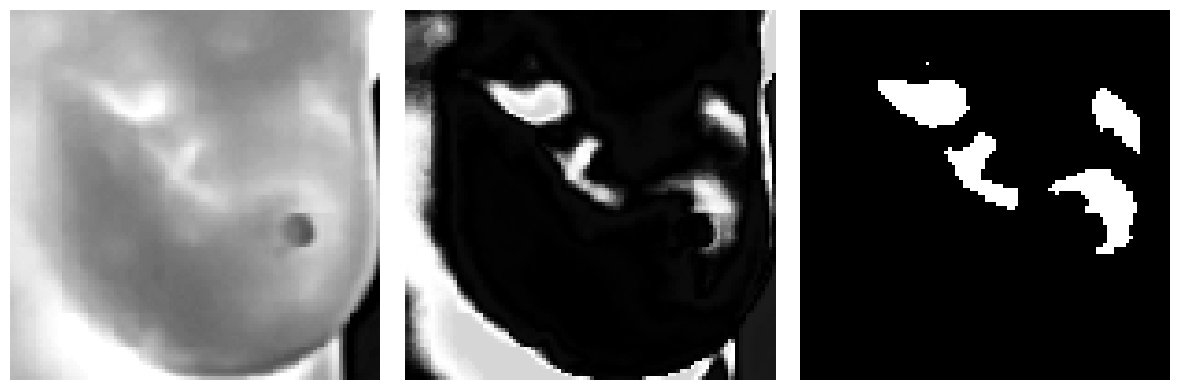

In [ ]:
binary_mask = (segmented_image_high_temp > 0.1).astype(np.uint8)
h, w = binary_mask.shape
non_island_mask = np.zeros((h + 2, w + 2), np.uint8) 
binary_with_border = binary_mask.copy()
for i in range(h):
    cv2.floodFill(binary_with_border, non_island_mask, (0, i), 2)         
    cv2.floodFill(binary_with_border, non_island_mask, (w-1, i), 2)       

for j in range(w):
    cv2.floodFill(binary_with_border, non_island_mask, (j, 0), 2)
    cv2.floodFill(binary_with_border, non_island_mask, (j, h-1), 2) 
islands_mask = (binary_with_border == 1).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(left, cmap='gray')
plt.title("Raw Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmented_image_high_temp, cmap='gray')
plt.title("Hottest Cluster")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(islands_mask, cmap='gray')
plt.title("Flood-Filled Islands Mask")
plt.axis('off')
plt.tight_layout()
plt.show()

## DBSCAN

/home/gabrielepassoni/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/gabrielepassoni/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


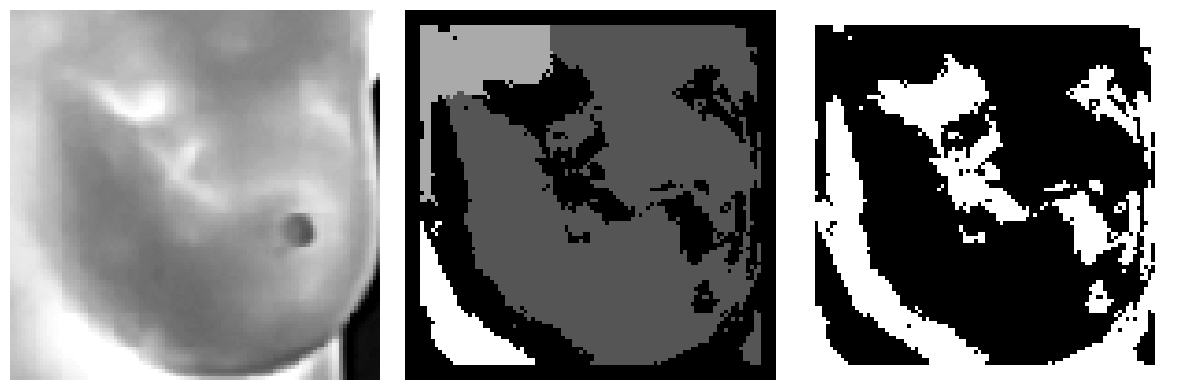

In [ ]:
import hdbscan

h, w = left.shape
img_norm = left.copy()

coords = np.indices((h, w)).transpose(1, 2, 0).reshape(-1, 2)
intensities = img_norm.flatten().reshape(-1, 1)
data = np.hstack((coords, intensities)) 

clusterer = hdbscan.HDBSCAN(min_cluster_size=75, metric='euclidean')
labels = clusterer.fit_predict(data)

label_map = labels.reshape(h, w)

mask_outliers = (label_map == -1).astype(np.uint8) * 255

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Raw Image")
plt.imshow(left, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"Clustered")
plt.imshow(label_map, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Unclustered Outliers")
plt.imshow(mask_outliers, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

/home/gabrielepassoni/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/gabrielepassoni/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


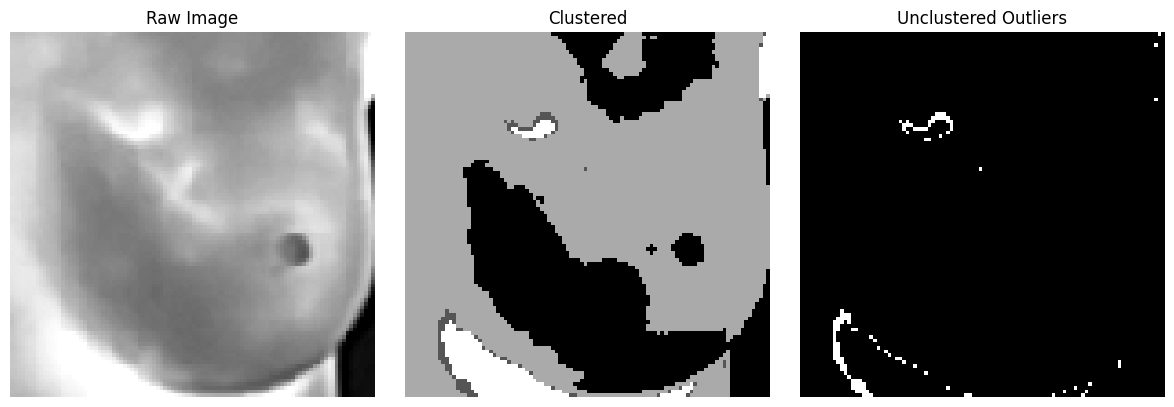

In [ ]:
import hdbscan
import numpy as np
import matplotlib.pyplot as plt
import cv2

h, w = left.shape
img_norm = cv2.normalize(left, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)

temp_threshold = np.percentile(img_norm, 30)
mask = img_norm > temp_threshold

coords = np.indices((h, w)).transpose(1, 2, 0).reshape(-1, 2)
intensities = img_norm.flatten().reshape(-1, 1)

coords = coords[mask.flatten()]
intensities = intensities[mask.flatten()]

coords_scaled = coords / np.array([[h, w]])
intensities_scaled = intensities * 10.0    
data = np.hstack((coords_scaled, intensities_scaled))
data = intensities_scaled

clusterer = hdbscan.HDBSCAN(min_cluster_size=200, metric='euclidean')
labels = clusterer.fit_predict(data)

label_map = np.full((h * w), -2, dtype=int)
flat_mask = mask.flatten()
label_map[flat_mask] = labels
label_map = label_map.reshape(h, w)

mask_outliers = (label_map == -1).astype(np.uint8) * 255

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Raw Image")
plt.imshow(left, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Clustered")
plt.imshow(label_map, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Unclustered Outliers")
plt.imshow(mask_outliers, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


## Spectral Clustering

/home/gabrielepassoni/.local/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


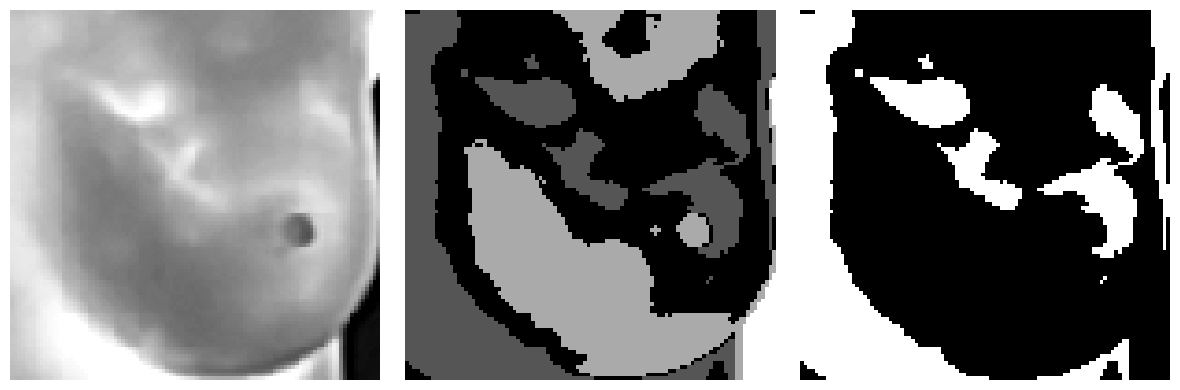

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler

img = left.copy()
h, w = left.shape

img_norm = cv2.normalize(img.astype(np.float32), None, 0, 1, cv2.NORM_MINMAX)

coords = np.indices((h, w)).transpose(1, 2, 0).reshape(-1, 2)  
intensities = img_norm.flatten().reshape(-1, 1)                

coords_scaled = coords / np.array([[h, w]])                    
intensity_weight = 3.0                                         
features = np.hstack((coords_scaled, intensities * intensity_weight))
features = intensities

features = StandardScaler().fit_transform(features)

n_clusters = 4  
spectral = SpectralClustering(
    n_clusters=n_clusters,
    affinity='nearest_neighbors',
    n_neighbors=10,
    assign_labels='kmeans',
    random_state=0
)
labels = spectral.fit_predict(features)

label_map = labels.reshape(h, w)

avg_temp_by_cluster = [
    img_norm.flatten()[labels == i].mean() for i in range(n_clusters)
]
hottest_cluster = np.argmax(avg_temp_by_cluster)
mask_hottest = (label_map == hottest_cluster).astype(np.uint8) * 255

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Raw Image")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Clustered")
plt.imshow(label_map, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Highest Temperature Cluster")
plt.imshow(mask_hottest, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

## GMM

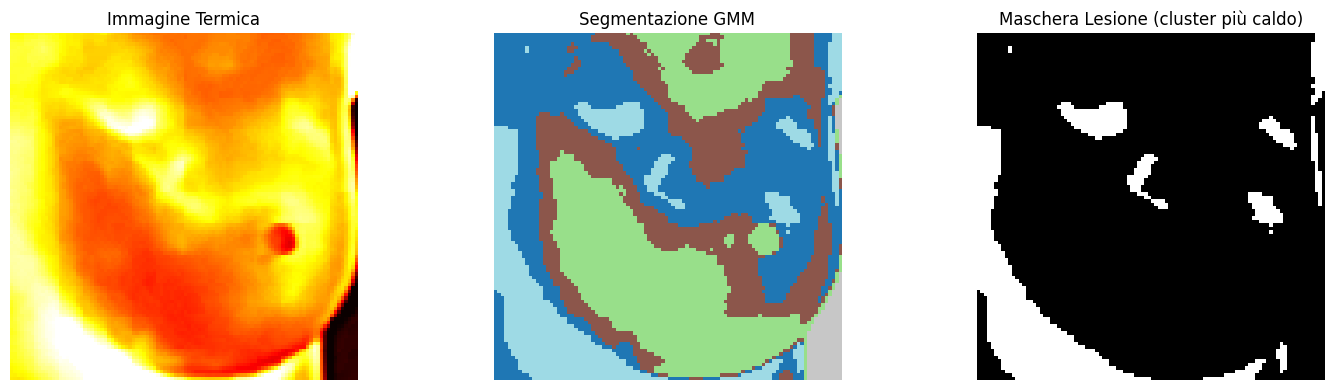

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

coords = np.indices((h, w)).transpose(1, 2, 0).reshape(-1, 2)
intensities = img_norm.flatten().reshape(-1, 1)

features = np.hstack((coords / np.array([[h, w]]), intensities * 4.0))  
features = intensities

n_components = 5  
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
gmm.fit(features)
labels = gmm.predict(features)

avg_temp_by_cluster = [
    img_norm.flatten()[labels == i].mean() for i in range(n_components)
]
hottest_cluster = np.argmax(avg_temp_by_cluster)
mask = (labels == hottest_cluster).astype(np.uint8).reshape(h, w) * 255
label_map = labels.reshape(h, w)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.title("Immagine Termica")
plt.imshow(img, cmap='hot')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Segmentazione GMM")
plt.imshow(label_map, cmap='tab20')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Maschera Lesione (cluster più caldo)")
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


## Uniformation of the background

/tmp/ipykernel_534951/905829366.py:7: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  mask_closed = closing(mask_initial, square(3))


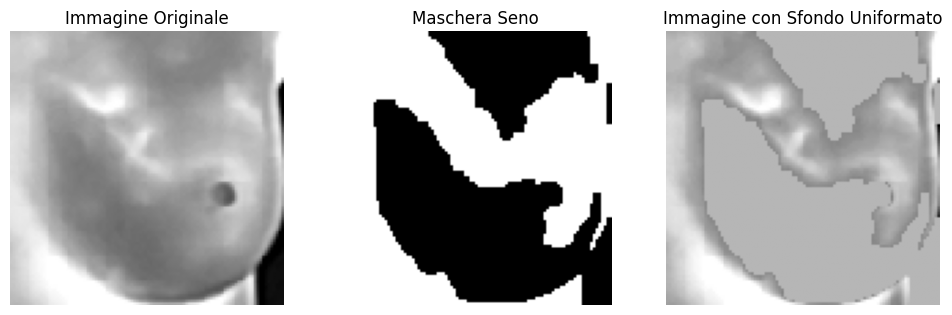

In [32]:
from skimage import img_as_float, morphology, measure, filters
from skimage.filters import threshold_otsu
from skimage.morphology import closing, square

thresh = threshold_otsu(left)
mask_initial = left > thresh 
mask_closed = closing(mask_initial, square(3))
labels = measure.label(mask_closed)
regions = measure.regionprops(labels)

if regions:
    largest_region = max(regions, key=lambda r: r.area)
    breast_mask = (labels == largest_region.label)
else:
    breast_mask = mask_closed  

background_fill = np.mean(left[breast_mask])

image_cleaned = left.copy()
image_cleaned[~breast_mask] = background_fill

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Immagine Originale")
plt.imshow(left, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Maschera Seno")
plt.imshow(breast_mask, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Immagine con Sfondo Uniformato")
plt.imshow(image_cleaned, cmap='gray')
plt.axis('off')
plt.show()

#left = image_cleaned

## Gradient Calculation and Viz

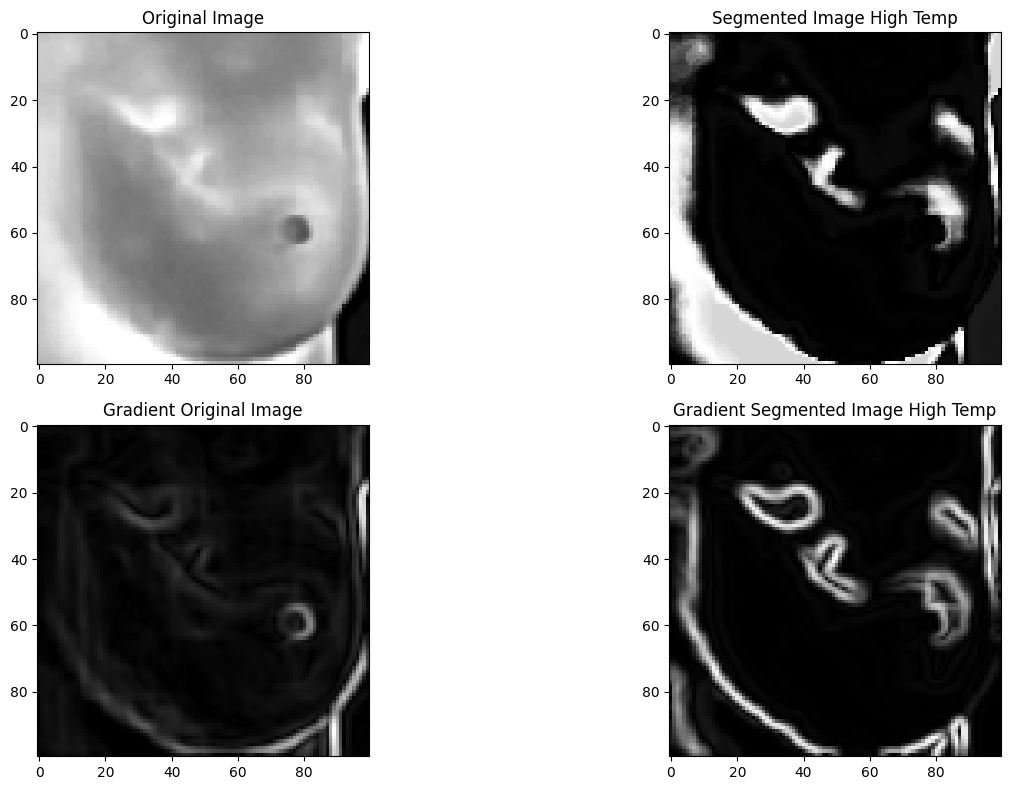

In [ ]:
def calculate_gradient(image):
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    return gradient_magnitude

gradient = calculate_gradient(left)
gradient_segmented = calculate_gradient(segmented_image_high_temp)

fig, ax = plt.subplots(2, 2, figsize=(15, 8))
ax[0, 0].imshow(left, cmap="gray")
ax[0, 0].set_title("Original Image")
ax[0, 1].imshow(segmented_image_high_temp, cmap="gray")
ax[0, 1].set_title("Segmented Image High Temp")
ax[1, 0].imshow(gradient, cmap="gray")
ax[1, 0].set_title("Gradient Original Image")
ax[1, 1].imshow(gradient_segmented, cmap="gray")
ax[1, 1].set_title("Gradient Segmented Image High Temp")
plt.tight_layout()
plt.show()

Cluster 0: Media = 1.5613, Std = 0.9267, Count = 8049
Cluster 1: Media = 23.6996, Std = 6.4836, Count = 219
Cluster 2: Media = 6.0002, Std = 2.5001, Count = 1732

➡️  Cluster con media pixel più alta: 1 (Media = 23.6996)


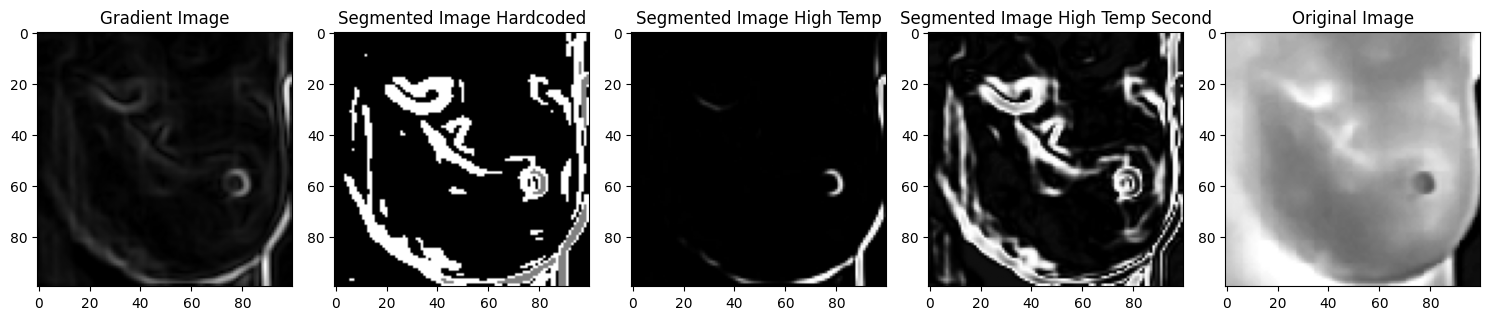

In [ ]:
pixels_gradient = gradient.flatten()
pixels_gradient = pixels_gradient[np.newaxis, :]
n_clusters = 3
m = 2.0

centers, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data = pixels_gradient,
    c = n_clusters,
    m = m,
    error = 0.005,
    maxiter = 1000,
    init = None,
)
hard_labels = np.argmax(u, axis=0)
segmented_image_hardcoded = hard_labels.reshape(gradient.shape)
pixels_gradient = pixels_gradient.flatten()
means = []
stds = []
for i in range(n_clusters):
    cluster_pixels = pixels_gradient[hard_labels == i]
    mean_val = cluster_pixels.mean()
    std_val = cluster_pixels.std()
    means.append(mean_val)
    stds.append(std_val)
    print(f"Cluster {i}: Media = {mean_val:.4f}, Std = {std_val:.4f}, Count = {len(cluster_pixels)}")

best_cluster = np.argmax(means)
second_best_cluster = np.argsort(means)[-2]
print(f"\n➡️  Cluster con media pixel più alta: {best_cluster} (Media = {means[best_cluster]:.4f})")
segmented_image_high_temp = u[best_cluster, :]
segmented_image_high_temp = segmented_image_high_temp.reshape(gradient.shape)
segmented_image_high_temp_second = u[second_best_cluster, :]
segmented_image_high_temp_second = segmented_image_high_temp_second.reshape(gradient.shape)

fig, ax = plt.subplots(1, 5, figsize=(15, 5))
ax[0].imshow(gradient, cmap="gray")
ax[0].set_title("Gradient Image")
ax[1].imshow(segmented_image_hardcoded, cmap="gray")
ax[1].set_title("Segmented Image Hardcoded")
ax[2].imshow(segmented_image_high_temp, cmap="gray")
ax[2].set_title("Segmented Image High Temp")
ax[3].imshow(segmented_image_high_temp_second, cmap="gray")
ax[3].set_title("Segmented Image High Temp Second")
ax[4].imshow(left, cmap="gray")
ax[4].set_title("Original Image")
plt.tight_layout()
plt.show()

## Region Growing

In [ ]:
from skimage.segmentation import flood

def select_seed_central_region(image, margin=0.15):
    h, w = image.shape
    r_min = int(margin * h)
    r_max = int((1 - margin) * h)
    c_min = int(margin * w)
    c_max = int((1 - margin) * w)
    central_region = image[r_min:r_max, c_min:c_max]
    weights = central_region.flatten().astype(np.float64)
    weights += 1e-6  
    weights /= weights.sum()
    chosen_idx = np.random.choice(np.arange(weights.size), p=weights)
    r_idx, c_idx = np.unravel_index(chosen_idx, central_region.shape)
    seed_point = (r_idx + r_min, c_idx + c_min)
    return seed_point

def select_seed_via_center_of_mass(image, margin=0.15, percentile=90):
    h, w = image.shape
    r_min = int(margin * h)
    r_max = int((1 - margin) * h)
    c_min = int(margin * w)
    c_max = int((1 - margin) * w)
    central_region = image[r_min:r_max, c_min:c_max]
    threshold = np.percentile(central_region, percentile)
    mask = central_region >= threshold
    if np.count_nonzero(mask) == 0:
        return ((r_min + r_max) // 2, (c_min + c_max) // 2)
    
    indices = np.argwhere(mask)
    center_mass = indices.mean(axis=0).astype(int)
    seed_point = (center_mass[0] + r_min, center_mass[1] + c_min)
    return tuple(seed_point)

def select_seed_stochastic(image, margin=0.15, percentile=90, radius=5):
    seed_center = select_seed_via_center_of_mass(image, margin, percentile)
    center_r, center_c = seed_center
    offset_r = int(np.random.normal(0, radius))
    offset_c = int(np.random.normal(0, radius))
    seed_r = np.clip(center_r + offset_r, 0, image.shape[0]-1)
    seed_c = np.clip(center_c + offset_c, 0, image.shape[1]-1)
    return (seed_r, seed_c)

def ensemble_region_growing(image, margin=0.15, percentile=90, radius=5, tolerance=0.1, iterations=10):
    masks = []
    for i in range(iterations):
        seed = select_seed_stochastic(image, margin, percentile, radius)
        mask = flood(image, seed_point=seed, tolerance=tolerance)
        masks.append(mask.astype(np.uint8))
    
    masks = np.array(masks)
    combined = np.mean(masks, axis=0)
    final_mask = (combined >= 0.5).astype(np.uint8)
    return final_mask

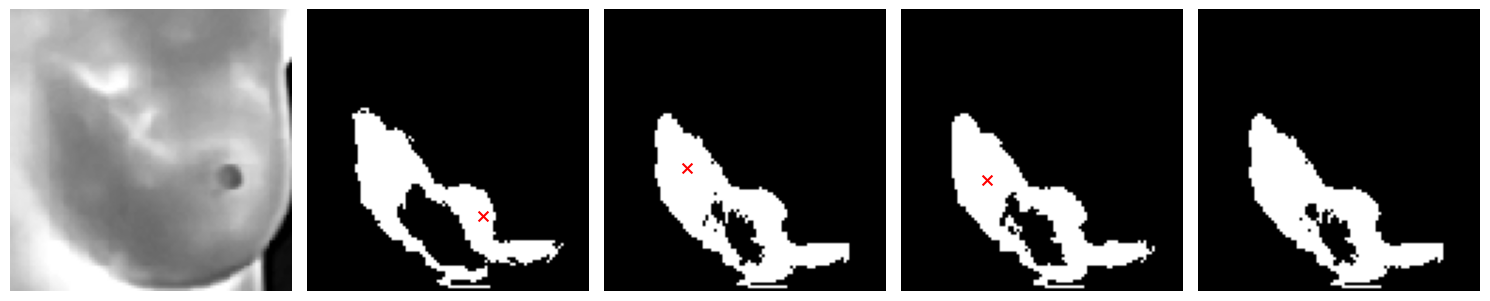

In [ ]:
tolerance = 0.05
margin= 0.10
radius = 5
percentile = 95

seed_margins = select_seed_central_region(left, margin=margin)
lesion_mask_margins = flood(left, seed_point=seed_margins, tolerance=tolerance)

seed_center = select_seed_via_center_of_mass(left, margin=margin, percentile=percentile)
lesion_mask_center = flood(left, seed_point=seed_center, tolerance=tolerance)

seed_stochastic = select_seed_stochastic(left, margin=margin, percentile=percentile, radius=radius)
lesion_mask_stochastic = flood(left, seed_point=seed_stochastic, tolerance=tolerance)

lesion_mask_ensemble = ensemble_region_growing(left, margin=margin, percentile=percentile, radius=radius, tolerance=tolerance, iterations=100)

fig, ax = plt.subplots(1, 5, figsize=(15, 5))
ax[0].imshow(left, cmap="gray")
ax[0].set_title("Raw Image")
ax[0].axis('off')
ax[1].imshow(lesion_mask_margins, cmap="gray")
ax[1].scatter(seed_margins[1], seed_margins[0], color='red', s=50, marker='x')
ax[1].set_title("Random Seed")
ax[1].axis('off')
ax[2].imshow(lesion_mask_center, cmap="gray")
ax[2].scatter(seed_center[1], seed_center[0], color='red', s=50, marker='x')
ax[2].set_title("Center of Mass Seed")
ax[2].axis('off')
ax[3].imshow(lesion_mask_stochastic, cmap="gray")
ax[3].scatter(seed_stochastic[1], seed_stochastic[0], color='red', s=50, marker='x')
ax[3].set_title("Stochastic Seed")
ax[3].axis('off')
ax[4].imshow(lesion_mask_ensemble, cmap="gray")
ax[4].set_title("Ensemble Region Growing")
ax[4].axis('off')
plt.tight_layout()
plt.show()